A language model assigns probabilities to sequences. Modern systems are large, but the core training objective is approachable: given previous tokens, predict the next token. This tutorial begins with the smallest useful model and then shows the calculation that lets transformers mix information across context.

## Learning goals

You will tokenize text into characters, estimate bigram probabilities, calculate negative log-likelihood, sample from a model, identify the bigram model's context limit, and implement causal scaled dot-product attention with NumPy.

## Next-token prediction

For tokens $x_1, \ldots, x_T$, an autoregressive model factorizes sequence probability as

$$
p(x_1, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_{<t}).
$$

Training minimizes average negative log-probability of the observed next tokens. A confident wrong prediction receives a large penalty.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corpus = (
    "data becomes useful when context is clear.\n"
    "models become useful when evidence is honest.\n"
    "code becomes useful when another person can run it.\n"
    "questions become useful when decisions are visible.\n"
) * 30

characters = sorted(set(corpus))
stoi = {character: index for index, character in enumerate(characters)}
itos = {index: character for character, index in stoi.items()}
start_token = len(characters)
vocab_size = len(characters) + 1
print(f"characters={len(corpus):,}, vocabulary={len(characters)} visible symbols")
print("vocabulary:", repr("".join(characters)))

characters=5,790, vocabulary=24 visible symbols
vocabulary: '\n .abcdefhilmnopqrstuvwx'


## 1. Tokenization defines the model's alphabet

A character tokenizer is transparent: one integer per character. Real language models often use subword tokens because they shorten sequences while retaining flexibility. Tokenization changes sequence length, vocabulary size, and which patterns are easy to learn.

In [2]:
example = "data is useful"
encoded = [stoi[character] for character in example]
decoded = "".join(itos[index] for index in encoded)
print("text:   ", example)
print("tokens: ", encoded)
print("decoded:", decoded)

text:    data is useful
tokens:  [6, 3, 19, 3, 1, 10, 18, 1, 20, 18, 7, 8, 20, 11]
decoded: data is useful


## 2. A bigram model remembers one token

Count every observed transition from a current character to the next one. Add a small smoothing value so unseen transitions have nonzero probability. A special start row models the first character.

In [3]:
counts = np.full((vocab_size, len(characters)), 0.25)
previous = start_token
for character in corpus:
    current = stoi[character]
    counts[previous, current] += 1
    previous = start_token if character == "\n" else current

probabilities = counts / counts.sum(axis=1, keepdims=True)

def likely_after(character, n=8):
    row = probabilities[stoi[character]]
    best = np.argsort(row)[-n:][::-1]
    return pd.DataFrame({"next_character": [repr(itos[i]) for i in best], "probability": row[best]})

likely_after("e").round(3)

,next_character,probability
0,'c',0.166
1,' ',0.166
2,'n',0.166
3,'s',0.133
4,'f',0.133
5,'r',0.067
6,'x',0.033
7,'v',0.033


## 3. Measure predictive surprise

Negative log-likelihood is small when the model gives high probability to the observed token. Averaging it over the corpus gives a training score in nats per character. A held-out score would be required to measure generalization.

In [4]:
negative_logs = []
previous = start_token
for character in corpus:
    current = stoi[character]
    negative_logs.append(-np.log(probabilities[previous, current]))
    previous = start_token if character == "\n" else current
print(f"training negative log-likelihood: {np.mean(negative_logs):.3f} nats/character")

training negative log-likelihood: 1.414 nats/character


## 4. Sampling converts probabilities into text

Greedy decoding always chooses the most likely token and can become repetitive. Sampling preserves alternatives. Temperature below 1 sharpens the distribution; temperature above 1 flattens it.

In [5]:
def sample_bigram(length=240, temperature=0.75, seed=3):
    local_rng = np.random.default_rng(seed)
    previous = start_token
    generated = []
    for _ in range(length):
        logits = np.log(probabilities[previous]) / temperature
        distribution = np.exp(logits - logits.max())
        distribution /= distribution.sum()
        current = local_rng.choice(len(characters), p=distribution)
        character = itos[current]
        generated.append(character)
        previous = start_token if character == "\n" else current
    return "".join(generated)

print(sample_bigram())

clen he ul isent.
me whesefuen bes ulen whes us whe ulecome.
mels whon whe dan whefusears ul usel ideful ion decome itaruserul cl con hen becomes becl whensul whe use ans ul ul ulefulels con usefus usis isen codest.
qul ul us visecome rus u


The sample resembles local spelling patterns but loses sentence-level meaning. The reason is structural: `p(next | current)` cannot distinguish two contexts that end in the same character. We need a way for each position to use a longer context.

## 5. Attention retrieves relevant context

Scaled dot-product attention forms a query, key, and value for every token:

$$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V.
$$

The query asks what the current position needs. Keys describe what each position offers. Their dot products become retrieval scores. Values are the information that gets mixed. A causal mask $M$ prevents a next-token model from reading future positions.

In [6]:
tokens = ["data", "becomes", "useful", "with", "context"]
dimension = 4
attention_rng = np.random.default_rng(9)
embeddings = attention_rng.normal(size=(len(tokens), dimension))
Wq = attention_rng.normal(scale=.45, size=(dimension, dimension))
Wk = attention_rng.normal(scale=.45, size=(dimension, dimension))
Wv = attention_rng.normal(scale=.45, size=(dimension, dimension))

Q, K, V = embeddings @ Wq, embeddings @ Wk, embeddings @ Wv
scores = Q @ K.T / np.sqrt(dimension)
causal_mask = np.triu(np.ones_like(scores, dtype=bool), k=1)
scores[causal_mask] = -np.inf
stable_scores = scores - np.max(scores, axis=1, keepdims=True)
weights = np.exp(stable_scores)
weights /= weights.sum(axis=1, keepdims=True)
contextualized = weights @ V

pd.DataFrame(weights, index=tokens, columns=tokens).round(3)

,data,becomes,useful,with,context
data,1.000,0.000,0.000,0.000,0.000
becomes,0.211,0.789,0.000,0.000,0.000
useful,0.107,0.791,0.102,0.000,0.000
with,0.364,0.092,0.481,0.063,0.000
context,0.166,0.169,0.216,0.181,0.269


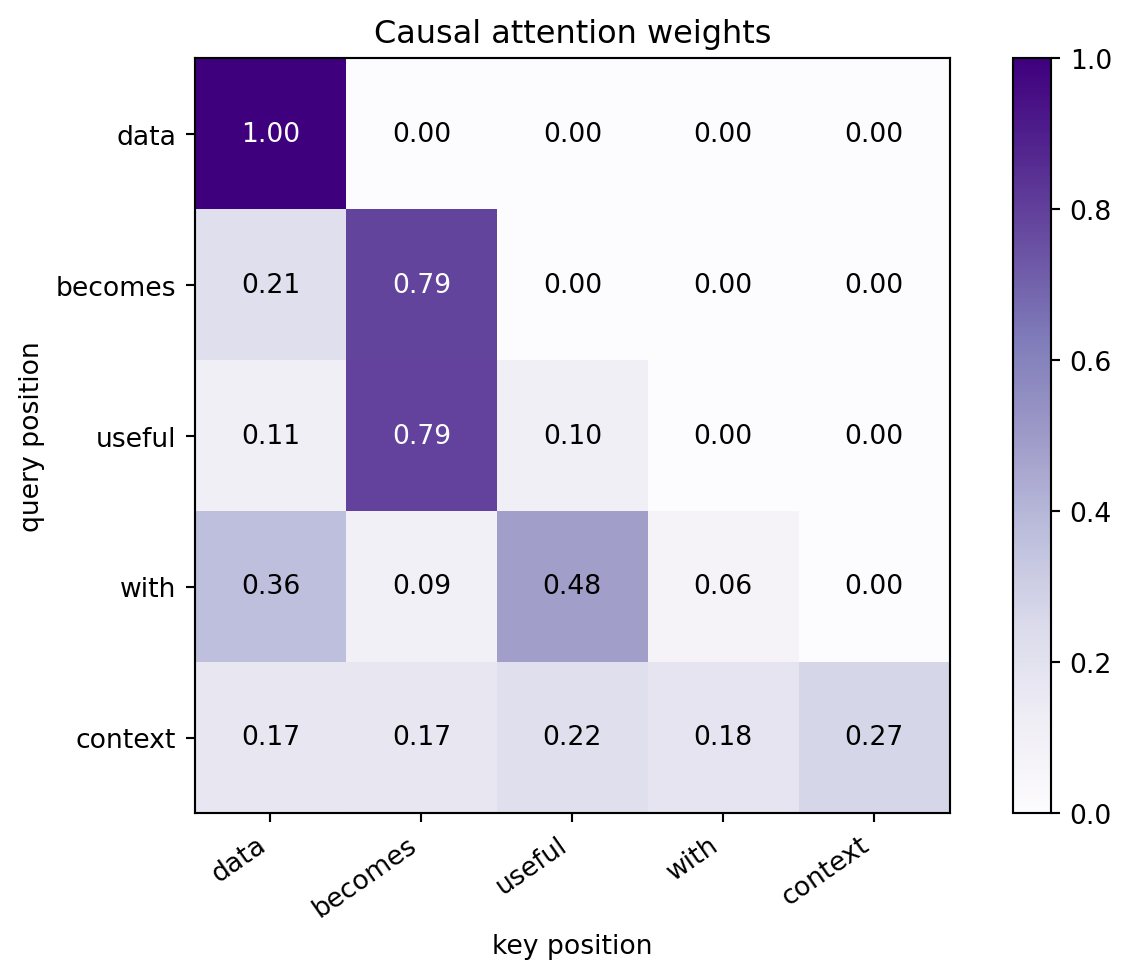

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
image = ax.imshow(weights, cmap="Purples", vmin=0, vmax=1)
ax.set(xticks=range(len(tokens)), yticks=range(len(tokens)), xticklabels=tokens, yticklabels=tokens, xlabel="key position", ylabel="query position", title="Causal attention weights")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
for row in range(len(tokens)):
    for col in range(len(tokens)):
        ax.text(col, row, f"{weights[row, col]:.2f}", ha="center", va="center", color="black" if weights[row, col] < .55 else "white")
fig.colorbar(image, ax=ax, fraction=.045)
plt.tight_layout()
plt.show()

## From this calculation to a transformer

A transformer learns the embeddings and projection matrices during training, uses several attention heads in parallel, adds positional information, applies feed-forward layers, normalization, and residual connections, and repeats the block many times. The final representation produces logits over the vocabulary.

The scaling, mask, softmax, and weighted value sum in the cell above remain the recognizable core. Attention weights are internal routing values; they are not automatically faithful explanations of a model's reasoning.

## Try it yourself

1. Hold out the last line of the corpus and compare train and validation negative log-likelihood.
2. Generate samples at temperatures `0.3`, `0.8`, and `1.5`; describe the quality–diversity tradeoff.
3. Remove the causal mask and identify exactly which weights leak future information.
4. Change one token embedding and measure how its entire attention row changes.

This completes the core **[Artificial Intelligence course](index.html)**.